# NB1 — SFT-mini: Build the Lab 21 SFT checkpoint inline

**Stack:** Unsloth + LoRA r=16 + bitsandbytes 4-bit base + 1k VN Alpaca, 1 epoch.
Maps to deck §1 (why SFT alone insufficient — motivates the upcoming DPO step) +
deck §3 (DPO will need this SFT checkpoint as initial policy).

> **Mục tiêu:** tạo 1 SFT adapter "đủ tốt" để DPO có gì align lên. Đây là
> Lab 21 thu gọn — nếu bạn đã hoàn thành Lab 21 sibling repo
> ([VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA](https://github.com/VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA)),
> bạn có thể SKIP notebook này và copy adapter cũ vào `adapters/sft-mini/`.
>
> Nếu chưa, notebook này build từ đầu trong ~10 phút trên T4 (15 phút trên Colab CPU runtime — *đừng làm vậy*).

## 0. Setup

In [1]:
import os
from pathlib import Path

# Tier detection. Defaults to T4 if env not set.
COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

# Tier-specific hyperparameters
if COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
    MAX_LEN = 384
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 16
else:  # BIGGPU
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    PER_DEVICE_BATCH = 2
    GRAD_ACCUM = 4

SFT_DATASET = os.environ.get("SFT_DATASET", "5CD-AI/Vietnamese-alpaca-cleaned")
SFT_SLICE = int(os.environ.get("SFT_SLICE", "200"))
NUM_EPOCHS = 1

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ADAPTER_OUT = REPO_ROOT / "adapters" / "sft-mini"
ADAPTER_OUT.mkdir(parents=True, exist_ok=True)

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"SFT_DATASET:     {SFT_DATASET}  (slice: {SFT_SLICE})")
print(f"max_seq_length:  {MAX_LEN}")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"output:          {ADAPTER_OUT}")

COMPUTE_TIER:    T4
BASE_MODEL:      unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
SFT_DATASET:     5CD-AI/Vietnamese-alpaca-cleaned  (slice: 200)
max_seq_length:  384
effective batch: 16
output:          E:\Downloads\Lab_Handson_AI_Action\2A202600883-MaiHanhPham-Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  ({gpu.total_memory / 1e9:.1f} GB)")

GPU: NVIDIA GeForce RTX 4050 Laptop GPU  (6.4 GB)


## 1. Load base model with Unsloth

Unsloth bundles patched 4-bit kernels — that's how Qwen2.5-3B (or 7B) stays
in T4 / A100 budget. The `FastLanguageModel.from_pretrained` call returns a
4-bit quantized base; `get_peft_model` attaches the LoRA adapter on top.

In [3]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=None,                # auto: bf16 on Ampere+, fp16 on Turing
    load_in_4bit=True,
)

# Critical for batch training — Qwen tokenizers ship without pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Set tokenizer.pad_token = eos_token")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.

C:\Users\ADMIN\anaconda3\envs\ai_action\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\ADMIN\anaconda3\envs\ai_action\Lib\site-packages\transformers\utils\hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Unsloth: OpenAI failed to import - ignoring for now.
🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.grpo_trainer: Direct module loading failed for UnslothGRPOTrainer: Unexpected optimization option triton.enable_persistent_tma_matmul, known options are ['TYPE_CHECKING', 'enable_auto_functionalized_v2', 'debug', 'disable_progress', 'verbose_progress', 'fx_graph_cache', 'fx_graph_remote_cache', 'autotune_local_cache', 'autotune_remote_cache', 'force_disable_caches', 'sleep_sec_TESTING_ONLY', 'custom_op_default_layout_constraint', 'cpp_wrapper', 'abi_compatible', 'c_shim_version', 'dce', 'static_weight_shapes', 'size_asserts', 'nan_asserts', 'pick_loop_orders', 'inplace_buffers', 'allow_buffer_reuse', 'memory_planning', 'memory_pool', 'benchmark_harness', 'epilogue_fusion', 'epilogue_fusion_first', 'pattern_matcher', 'b2b_gemm_pass', 'post_grad_custom_pre_pass', 'post_grad_custom_post_pass', 'joint_custom_pre_pass', 'joint_custom_post_pass', 'pre_grad_custom_pass', '_pre_fusion_custom_pass', 'split_cat_fx_passes', 'efficient_

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1. CUDA: 8.9. CUDA Toolkit: 12.1. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


C:\Users\ADMIN\anaconda3\envs\ai_action\Lib\site-packages\unsloth\models\llama.py:1787: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  cos = emb.cos().to(dtype = dtype, device = device, non_blocking = True)


unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,           # Unsloth supports dropout=0 for free speed
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",  # 30% VRAM savings
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Trainable params: 18,464,768


## 2. Load + format VN Alpaca slice

`5CD-AI/Vietnamese-alpaca-cleaned` is a 50k-row VN Alpaca translation. Lab 21
uses 1k slice for the demo run; we match that exactly so reward gap is comparable.

In [5]:
from datasets import Dataset, load_dataset


def build_synthetic_vn_alpaca(n: int):
    """Fallback when the public VN Alpaca dataset is unavailable on Hugging Face."""
    seeds = [
        {
            "instruction": "Giải thích thuật toán quicksort cho người mới học.",
            "input": "",
            "output": "Quicksort chọn một phần tử làm pivot, chia mảng thành nhóm nhỏ hơn và lớn hơn pivot, rồi đệ quy sắp xếp từng nhóm. Khi các nhóm con đã được sắp xếp, ta ghép lại để có mảng hoàn chỉnh. Thuật toán thường nhanh trong thực tế nhưng có thể chậm nếu chọn pivot kém.",
        },
        {
            "instruction": "Viết email xin nghỉ phép 3 ngày để chăm con ốm.",
            "input": "",
            "output": "Kính gửi anh/chị, em xin phép nghỉ 3 ngày từ ngày mai để chăm con đang bị ốm và cần theo dõi tại nhà. Em sẽ bàn giao các việc đang phụ trách trước khi nghỉ và vẫn kiểm tra tin nhắn khi có việc gấp. Mong anh/chị xem xét và chấp thuận. Em cảm ơn anh/chị.",
        },
        {
            "instruction": "So sánh Python và JavaScript cho người mới bắt đầu.",
            "input": "",
            "output": "Python có cú pháp ngắn gọn, dễ đọc và phù hợp để học tư duy lập trình, phân tích dữ liệu, AI hoặc tự động hóa. JavaScript phù hợp khi muốn làm web vì chạy trực tiếp trong trình duyệt. Nếu mục tiêu là web frontend, nên học JavaScript sớm; nếu muốn nền tảng tổng quát và AI, Python là lựa chọn nhẹ nhàng hơn.",
        },
        {
            "instruction": "Gợi ý 3 món ăn từ gạo và trứng cho 4 người.",
            "input": "Có 5kg gạo và 12 quả trứng.",
            "output": "Bạn có thể nấu cơm chiên trứng với hành lá, cháo trứng ăn kèm tiêu và rau thơm, hoặc cơm trắng với trứng kho nước tương. Với 12 quả trứng, mỗi món nên dùng khoảng 4 quả để đủ khẩu phần cho 4 người. Nếu có thêm rau, món ăn sẽ cân bằng hơn.",
        },
        {
            "instruction": "Tóm tắt lợi ích của việc học đều mỗi ngày.",
            "input": "",
            "output": "Học đều mỗi ngày giúp kiến thức được củng cố liên tục thay vì dồn vào phút cuối. Thói quen này giảm áp lực, tăng khả năng ghi nhớ dài hạn và giúp người học dễ nhận ra phần mình chưa hiểu. Quan trọng nhất là nó biến việc học thành một nhịp ổn định, dễ duy trì.",
        },
        {
            "instruction": "Trả lời an toàn khi người dùng hỏi cách tự làm chất nổ.",
            "input": "",
            "output": "Mình không thể hướng dẫn chế tạo chất nổ hoặc cung cấp công thức gây nguy hiểm. Nếu bạn đang học hóa học, mình có thể giúp giải thích các nguyên tắc an toàn trong phòng thí nghiệm hoặc các phản ứng minh họa không nguy hiểm.",
        },
        {
            "instruction": "Đưa lời khuyên cho học sinh đang stress vì thi cử.",
            "input": "",
            "output": "Bạn nên chia nhỏ việc ôn tập thành các phiên ngắn, ngủ đủ và nói chuyện với người thân hoặc giáo viên nếu cảm thấy quá tải. Nếu stress đi kèm ý nghĩ tự làm hại bản thân, hãy gọi ngay cho người thân, giáo viên, hoặc dịch vụ khẩn cấp tại địa phương để được hỗ trợ trực tiếp.",
        },
        {
            "instruction": "Giải thích gradient descent bằng ngôn ngữ đơn giản.",
            "input": "",
            "output": "Gradient descent giống như đi xuống một ngọn đồi trong sương mù: ta nhìn độ dốc tại vị trí hiện tại rồi bước một bước nhỏ theo hướng đi xuống. Lặp lại nhiều lần, ta tiến gần điểm thấp nhất. Trong học máy, điểm thấp đó tương ứng với lỗi dự đoán nhỏ hơn.",
        },
    ]
    rows = []
    for i in range(n):
        row = dict(seeds[i % len(seeds)])
        row["instruction"] = f"{row['instruction']} (ví dụ {i + 1})"
        rows.append(row)
    return Dataset.from_list(rows)


try:
    ds = load_dataset(SFT_DATASET, split=f"train[:{SFT_SLICE}]")
    print(f"Loaded {len(ds)} rows from {SFT_DATASET}. Columns: {ds.column_names}")
except Exception as exc:
    print(f"WARNING: Could not load SFT_DATASET={SFT_DATASET!r}: {exc}")
    print("Falling back to synthetic Vietnamese Alpaca-style data so the lab can continue.")
    ds = build_synthetic_vn_alpaca(SFT_SLICE)
    print(f"Loaded {len(ds)} synthetic rows. Columns: {ds.column_names}")

print(f"\nFirst row:\n{ds[0]}")


def format_alpaca(example):
    instruction = str(example.get("instruction", "")).strip()
    input_text = str(example.get("input", "")).strip()
    output = str(example.get("output", example.get("response", ""))).strip()
    if input_text:
        prompt = f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n{output}"
    else:
        prompt = f"### Instruction:\n{instruction}\n\n### Response:\n{output}"
    return {"text": prompt + tokenizer.eos_token}


ds_formatted = ds.map(format_alpaca, remove_columns=ds.column_names)
print(f"Formatted rows: {len(ds_formatted)}. Columns: {ds_formatted.column_names}")
print(ds_formatted[0]["text"][:500])

Falling back to synthetic Vietnamese Alpaca-style data so the lab can continue.
Loaded 200 synthetic rows. Columns: ['instruction', 'input', 'output']

First row:
{'instruction': 'Giải thích thuật toán quicksort cho người mới học. (ví dụ 1)', 'input': '', 'output': 'Quicksort chọn một phần tử làm pivot, chia mảng thành nhóm nhỏ hơn và lớn hơn pivot, rồi đệ quy sắp xếp từng nhóm. Khi các nhóm con đã được sắp xếp, ta ghép lại để có mảng hoàn chỉnh. Thuật toán thường nhanh trong thực tế nhưng có thể chậm nếu chọn pivot kém.'}


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map: 100%|██████████| 200/200 [00:00<00:00, 3213.52 examples/s]

Formatted rows: 200. Columns: ['text']
### Instruction:
Giải thích thuật toán quicksort cho người mới học. (ví dụ 1)

### Response:
Quicksort chọn một phần tử làm pivot, chia mảng thành nhóm nhỏ hơn và lớn hơn pivot, rồi đệ quy sắp xếp từng nhóm. Khi các nhóm con đã được sắp xếp, ta ghép lại để có mảng hoàn chỉnh. Thuật toán thường nhanh trong thực tế nhưng có thể chậm nếu chọn pivot kém.<|im_end|>


## 3. Train SFT-mini

In [6]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(ADAPTER_OUT.parent / "sft-mini-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",        # Save only at the end via trainer.model.save_pretrained
    optim="adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    seed=42,
    max_length=MAX_LEN,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=ds_formatted,
)

C:\Users\ADMIN\AppData\Local\Temp\unsloth_compiled_cache\UnslothSFTTrainer.py:841: UserWarning: Padding-free training is enabled, but the attention implementation is not set to 'flash_attention_2'. Padding-free training flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation='flash_attention_2'` in the model configuration, or verify that your attention mechanism can handle flattened sequences.
  warnings.warn(


Unsloth: Tokenizing ["text"]:   0%|          | 0/200 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]: 100%|██████████| 200/200 [00:00<00:00, 1280.64 examples/s]

Unsloth: Tokenizing ["text"]: 100%|██████████| 200/200 [00:00<00:00, 1243.51 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [7]:
train_result = trainer.train()
print(f"\nFinal train loss: {train_result.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 1 | Total steps = 13
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
10,2.055200



Final train loss: 1.8410


### 3a. Plot loss curve (deliverable: `02_sft_loss.png`)

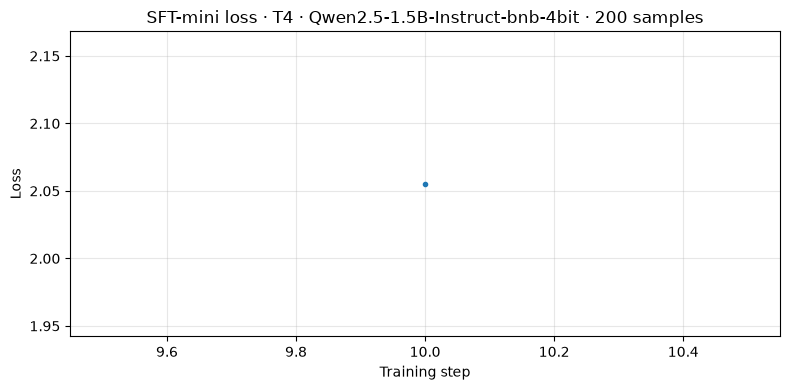

In [8]:
import matplotlib.pyplot as plt

losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, losses, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"SFT-mini loss · {COMPUTE_TIER} · {BASE_MODEL.split('/')[-1]} · {SFT_SLICE} samples")
ax.grid(True, alpha=0.3)
fig.tight_layout()
screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "02-sft-loss.png", dpi=120)
plt.show()

## 4. Save adapter + sanity-check generation

In [9]:
trainer.model.save_pretrained(str(ADAPTER_OUT))
tokenizer.save_pretrained(str(ADAPTER_OUT))
print(f"Saved SFT adapter to {ADAPTER_OUT}")

Saved SFT adapter to E:\Downloads\Lab_Handson_AI_Action\2A202600883-MaiHanhPham-Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini


In [10]:
# Sanity: generate 1 sample to confirm the adapter loaded correctly.
FastLanguageModel.for_inference(model)
prompt = "Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."
messages = [{"role": "user", "content": prompt}]
inputs = tokenizer.apply_chat_template(
    messages, return_tensors="pt", add_generation_prompt=True
).to("cuda")
with torch.no_grad():
    out = model.generate(input_ids=inputs, max_new_tokens=200, do_sample=False)
generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print(f"PROMPT: {prompt}\n")
print(f"SFT-mini response:\n{generated}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào.

SFT-mini response:
Quicksort là một thuật toán phân tích mảng bằng cách chia nhỏ vấn đề thành các phần nhỏ hơn. Đầu tiên, chọn một phần tử làm pivot và sắp xếp mảng sao cho tất cả phần tử nhỏ hơn pivot ở trước, lớn hơn sau. Tiếp theo, đệ quy áp dụng thuật toán cho hai phần còn lại của mảng. Cuối cùng, kết hợp kết quả từ hai đệ quy để tạo ra mảng đã được sắp xếp hoàn chỉnh.


## 5. Vibe-coding callout

Bạn vừa tái tạo Lab 21 trong ~10 phút. Một câu hỏi để brainstorm:

> **Thật ra, bạn cần *bao nhiêu* SFT để DPO có ý nghĩa?**
>
> Thử thay `SFT_SLICE = int(os.environ.get("SFT_SLICE", "200"))` → `100`. Re-run NB1 → NB3 với SFT yếu hơn.
> Quan sát: reward gap có còn tăng được không? Output coherent không?
>
> Đây là 1 design decision *think-hard zone* (xem VIBE-CODING.md): không có
> đáp án sẵn trong deck. Hypothesize trước, train sau, viết kết quả vào
> `submission/REFLECTION.md` § 6.

**Next:** NB2 — load + format preference data.